In [ ]:
!pip install kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("techzizou/labeled-mask-dataset-yolo-darknet")

print("Path to dataset files:", path)

100%|██████████| 126M/126M [00:01<00:00, 97.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/techzizou/labeled-mask-dataset-yolo-darknet/versions/1


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install ultralytics kaggle -q

ValueError: Mountpoint must not already contain files

In [ ]:
from google.colab import files
files.upload()  # a file picker will appear

{}

In [ ]:
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d techzizou/labeled-mask-dataset-yolo-darknet
!unzip -q labeled-mask-dataset-yolo-darknet.zip -d /content/mask_raw

Dataset URL: https://www.kaggle.com/datasets/techzizou/labeled-mask-dataset-yolo-darknet
License(s): CC0-1.0
100% 126M/126M [00:01<00:00, 118MB/s]



In [ ]:
import os

# Create a folder in your Drive
drive_path = '/content/drive/MyDrive/mask_project/mask_raw'
os.makedirs(drive_path, exist_ok=True)

# Unzip directly into Drive
!unzip -q labeled-mask-dataset-yolo-darknet.zip -d /content/drive/MyDrive/mask_project/mask_raw

In [ ]:
import os, shutil

base    = '/content/drive/MyDrive/mask_detection_yolo_model/data'
src     = f'{base}/obj'
img_dst = f'{base}/images'
lbl_dst = f'{base}/labels'

os.makedirs(img_dst, exist_ok=True)
os.makedirs(lbl_dst, exist_ok=True)

imgs, txts = 0, 0

for f in os.listdir(src):
    src_path = f'{src}/{f}'
    if f.endswith(('.jpg', '.jpeg', '.png')):
        shutil.copy(src_path, f'{img_dst}/{f}')
        imgs += 1
    elif f.endswith('.txt'):
        shutil.copy(src_path, f'{lbl_dst}/{f}')
        txts += 1

print(f"Images copied : {imgs}")
print(f"Labels copied : {txts}")
print("Done ✓")

Images copied : 1510
Labels copied : 1510
Done ✓


In [ ]:
import os, shutil, random

random.seed(42)

base    = '/content/drive/MyDrive/mask_detection_yolo_model/data'
img_src = f'{base}/images'
lbl_src = f'{base}/labels'

# Create split folders
for split in ['train', 'val', 'test']:
    os.makedirs(f'{img_src}/{split}', exist_ok=True)
    os.makedirs(f'{lbl_src}/{split}', exist_ok=True)

# Get all images and shuffle
imgs = [f for f in os.listdir(img_src) if f.endswith(('.jpg', '.jpeg', '.png'))]
random.shuffle(imgs)

n      = len(imgs)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

splits = {
    'train': imgs[:n_train],
    'val'  : imgs[n_train:n_train + n_val],
    'test' : imgs[n_train + n_val:]
}

# Move files
for split, files in splits.items():
    for f in files:
        base_name = os.path.splitext(f)[0]
        lbl_file  = base_name + '.txt'

        shutil.move(f'{img_src}/{f}',        f'{img_src}/{split}/{f}')

        if os.path.exists(f'{lbl_src}/{lbl_file}'):
            shutil.move(f'{lbl_src}/{lbl_file}', f'{lbl_src}/{split}/{lbl_file}')

    print(f"{split:5} → {len(files):3} images")

print("\nDone ✓")
"""
mask_detection_yolo_model/data/
├── images/
│   ├── train/   ← 682 images
│   ├── val/     ← 85  images
│   └── test/    ← 86  images
└── labels/
    ├── train/   ← 682 .txt files
    ├── val/     ← 85  .txt files
    └── test/    ← 86  .txt files
"""

train → 1208 images
val   → 151 images
test  → 151 images

Done ✓


'\nmask_detection_yolo_model/data/\n├── images/\n│   ├── train/   ← 682 images\n│   ├── val/     ← 85  images\n│   └── test/    ← 86  images\n└── labels/\n    ├── train/   ← 682 .txt files\n    ├── val/     ← 85  .txt files\n    └── test/    ← 86  .txt files\n'

In [ ]:
yaml_content = """
path: /content/drive/MyDrive/mask_detection_yolo_model/data
train: images/train
val:   images/val
test:  images/test

nc: 2
names: ['with_mask', 'without_mask']
"""

# Save yaml to Drive
with open('/content/drive/MyDrive/mask_detection_yolo_model/mask.yaml', 'w') as f:
    f.write(yaml_content)

print("mask.yaml created ✓")

mask.yaml created ✓


Cell 1 — check label format is valid YOLO (5 values per line, all between 0 and 1):


In [ ]:
import os

lbl_train = '/content/drive/MyDrive/mask_detection_yolo_model/data/labels/train'

bad = []
for txt in os.listdir(lbl_train):
    with open(f'{lbl_train}/{txt}') as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) != 5:
                bad.append(f"{txt} line {i+1} — expected 5 values, got {len(parts)}")
                continue
            cid, cx, cy, bw, bh = map(float, parts)
            if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < bw <= 1 and 0 < bh <= 1):
                bad.append(f"{txt} line {i+1} — values out of range: {parts}")
            if int(cid) not in (0, 1):
                bad.append(f"{txt} line {i+1} — unknown class id: {int(cid)}")

if bad:
    print(f"Found {len(bad)} issues:")
    for b in bad[:10]: print(" ", b)
else:
    print("All labels are valid YOLO format ✓")

Found 1 issues:
  with_mask (3).txt line 91 — values out of range: ['0', '0.431', '0.4935158501440922', '0', '0']


In [ ]:
file_path = '/content/drive/MyDrive/mask_detection_yolo_model/data/labels/train/with_mask (3).txt'

widths = []
heights = []
lines = []

#  Lire le fichier
with open(file_path, 'r') as f:
    lines = f.readlines()

#  Calcul des moyennes (en ignorant les 0)
for line in lines:
    parts = line.strip().split()
    if len(parts) != 5:
        continue

    _, _, _, w, h = map(float, parts)

    if w > 0 and h > 0:
        widths.append(w)
        heights.append(h)

#  Moyennes
avg_w = sum(widths) / len(widths)
avg_h = sum(heights) / len(heights)

print(f"Average width  = {avg_w}")
print(f"Average height = {avg_h}")

#  Correction de la ligne invalide
new_lines = []
for line in lines:
    parts = line.strip().split()

    if len(parts) != 5:
        new_lines.append(line)
        continue

    cid, cx, cy, w, h = map(float, parts)

    #  détecter bbox invalide
    if w == 0 and h == 0:
        print("Fixing invalid line...")
        w = avg_w
        h = avg_h

    new_lines.append(f"{int(cid)} {cx} {cy} {w} {h}\n")

# Sauvegarde
with open(file_path, 'w') as f:
    f.writelines(new_lines)

print("File corrected using mean values ✓")

Average width  = 0.034450892857142854
Average height = 0.05680063812268423
Fixing invalid line...
File corrected using mean values ✓


In [ ]:
from collections import Counter

names = {0: 'with_mask', 1: 'without_mask'}
counts = Counter()

for txt in os.listdir(lbl_train):
    with open(f'{lbl_train}/{txt}') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                counts[int(parts[0])] += 1

total = sum(counts.values())
for cid, cnt in sorted(counts.items()):
    pct = 100 * cnt / total
    print(f"  class {cid} ({names[cid]:15}) → {cnt:4} boxes  ({pct:.1f}%)")

  class 0 (with_mask      ) → 1550 boxes  (76.2%)
  class 1 (without_mask   ) →  485 boxes  (23.8%)


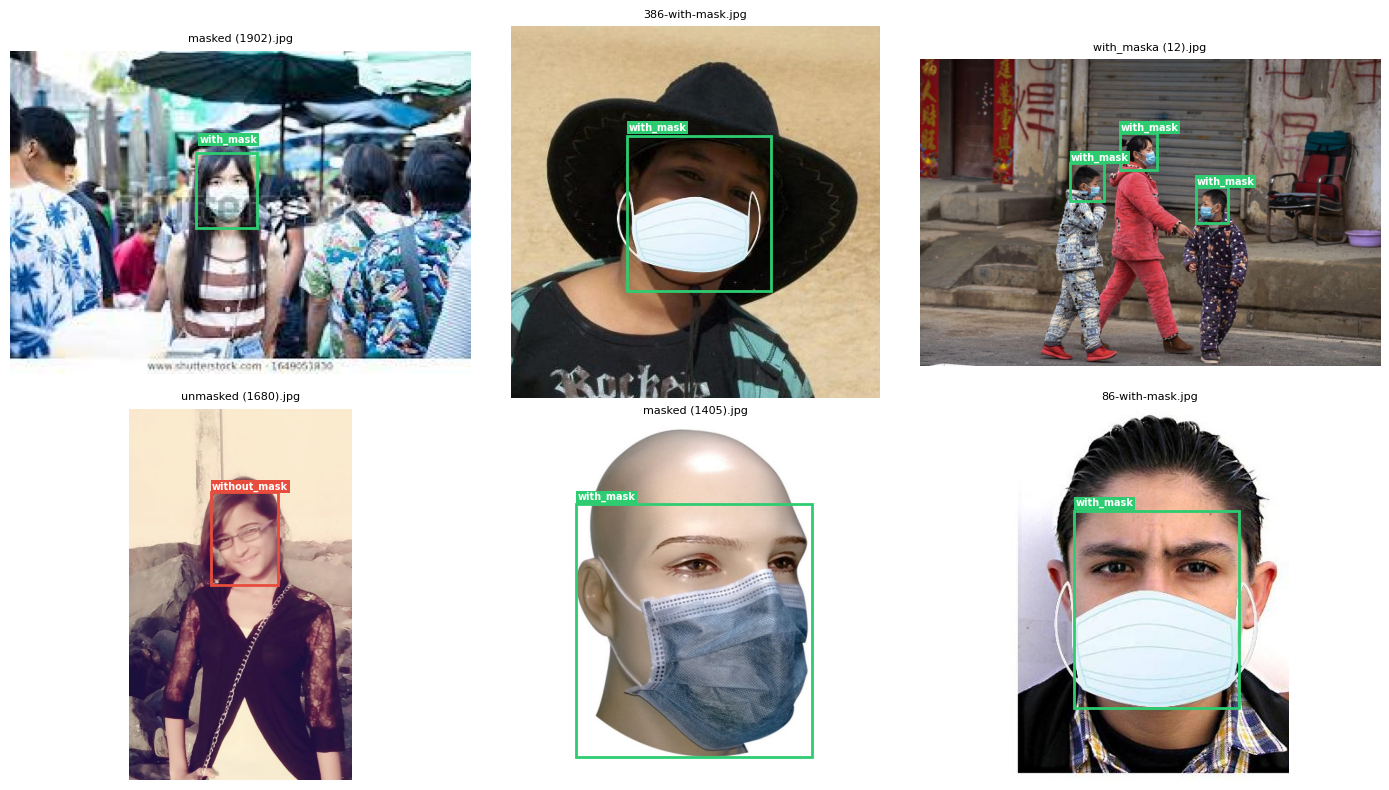

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

img_train = '/content/drive/MyDrive/mask_detection_yolo_model/data/images/train'
lbl_train = '/content/drive/MyDrive/mask_detection_yolo_model/data/labels/train'

colors = {0: '#2ecc71', 1: '#e74c3c'}
names  = {0: 'with_mask', 1: 'without_mask'}

samples = random.sample(os.listdir(img_train), 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, img_file in zip(axes, samples):
    img  = Image.open(f'{img_train}/{img_file}')
    W, H = img.size
    ax.imshow(img)

    lbl_file = os.path.splitext(img_file)[0] + '.txt'
    lbl_path = f'{lbl_train}/{lbl_file}'

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                cid, cx, cy, bw, bh = map(float, line.strip().split())
                cid = int(cid)
                x = (cx - bw/2) * W
                y = (cy - bh/2) * H
                rect = patches.Rectangle(
                    (x, y), bw*W, bh*H,
                    linewidth=2, edgecolor=colors[cid], facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x+2, y-6, names[cid],
                        color='white', fontsize=7, fontweight='bold',
                        bbox=dict(facecolor=colors[cid], pad=1, edgecolor='none'))

    ax.set_title(img_file, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO


model = YOLO('yolov8n.pt')  # auto-downloads pretrained weights

results = model.train(
    data   = '/content/drive/MyDrive/mask_detection_yolo_model/mask.yaml',
    epochs = 50,
    imgsz  = 640,
    batch  = 16,
    name   = 'mask_detector',
    project= '/content/drive/MyDrive/mask_detection_yolo_model'
)

print("Training complete ✓")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/mask_detection_yolo_model/mask.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mask_detector4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [ ]:
best_path = '/content/drive/MyDrive/mask_detection_yolo_model/mask_detector4/weights/best.pt'
import os
print("Saved:", os.path.exists(best_path))  # True

Saved: True


In [ ]:
from ultralytics import YOLO

# Load YOUR trained model, not the pretrained one
model = YOLO('/content/drive/MyDrive/mask_detection_yolo_model/mask_detector4/weights/best.pt')

metrics = model.val(
    data  = '/content/drive/MyDrive/mask_detection_yolo_model/mask.yaml',
    split = 'test'
)

print(f"mAP50:     {metrics.box.map50:.3f}")
print(f"Precision: {metrics.box.p.mean():.3f}")
print(f"Recall:    {metrics.box.r.mean():.3f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 20.3±17.2 MB/s, size: 35.2 KB)
val: Scanning /content/drive/MyDrive/mask_detection_yolo_model/data/labels/test.cache... 151 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 151/151 52.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.7it/s 3.7s
                   all        151        267       0.91      0.843      0.931      0.645
             with_mask        108        216      0.884      0.829      0.893      0.561
          without_mask         46         51      0.936      0.858      0.969      0.729
Speed: 4.7ms preprocess, 4.4ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/val2
mAP50:     0.931
Precision: 0.910
Recall:    0.843


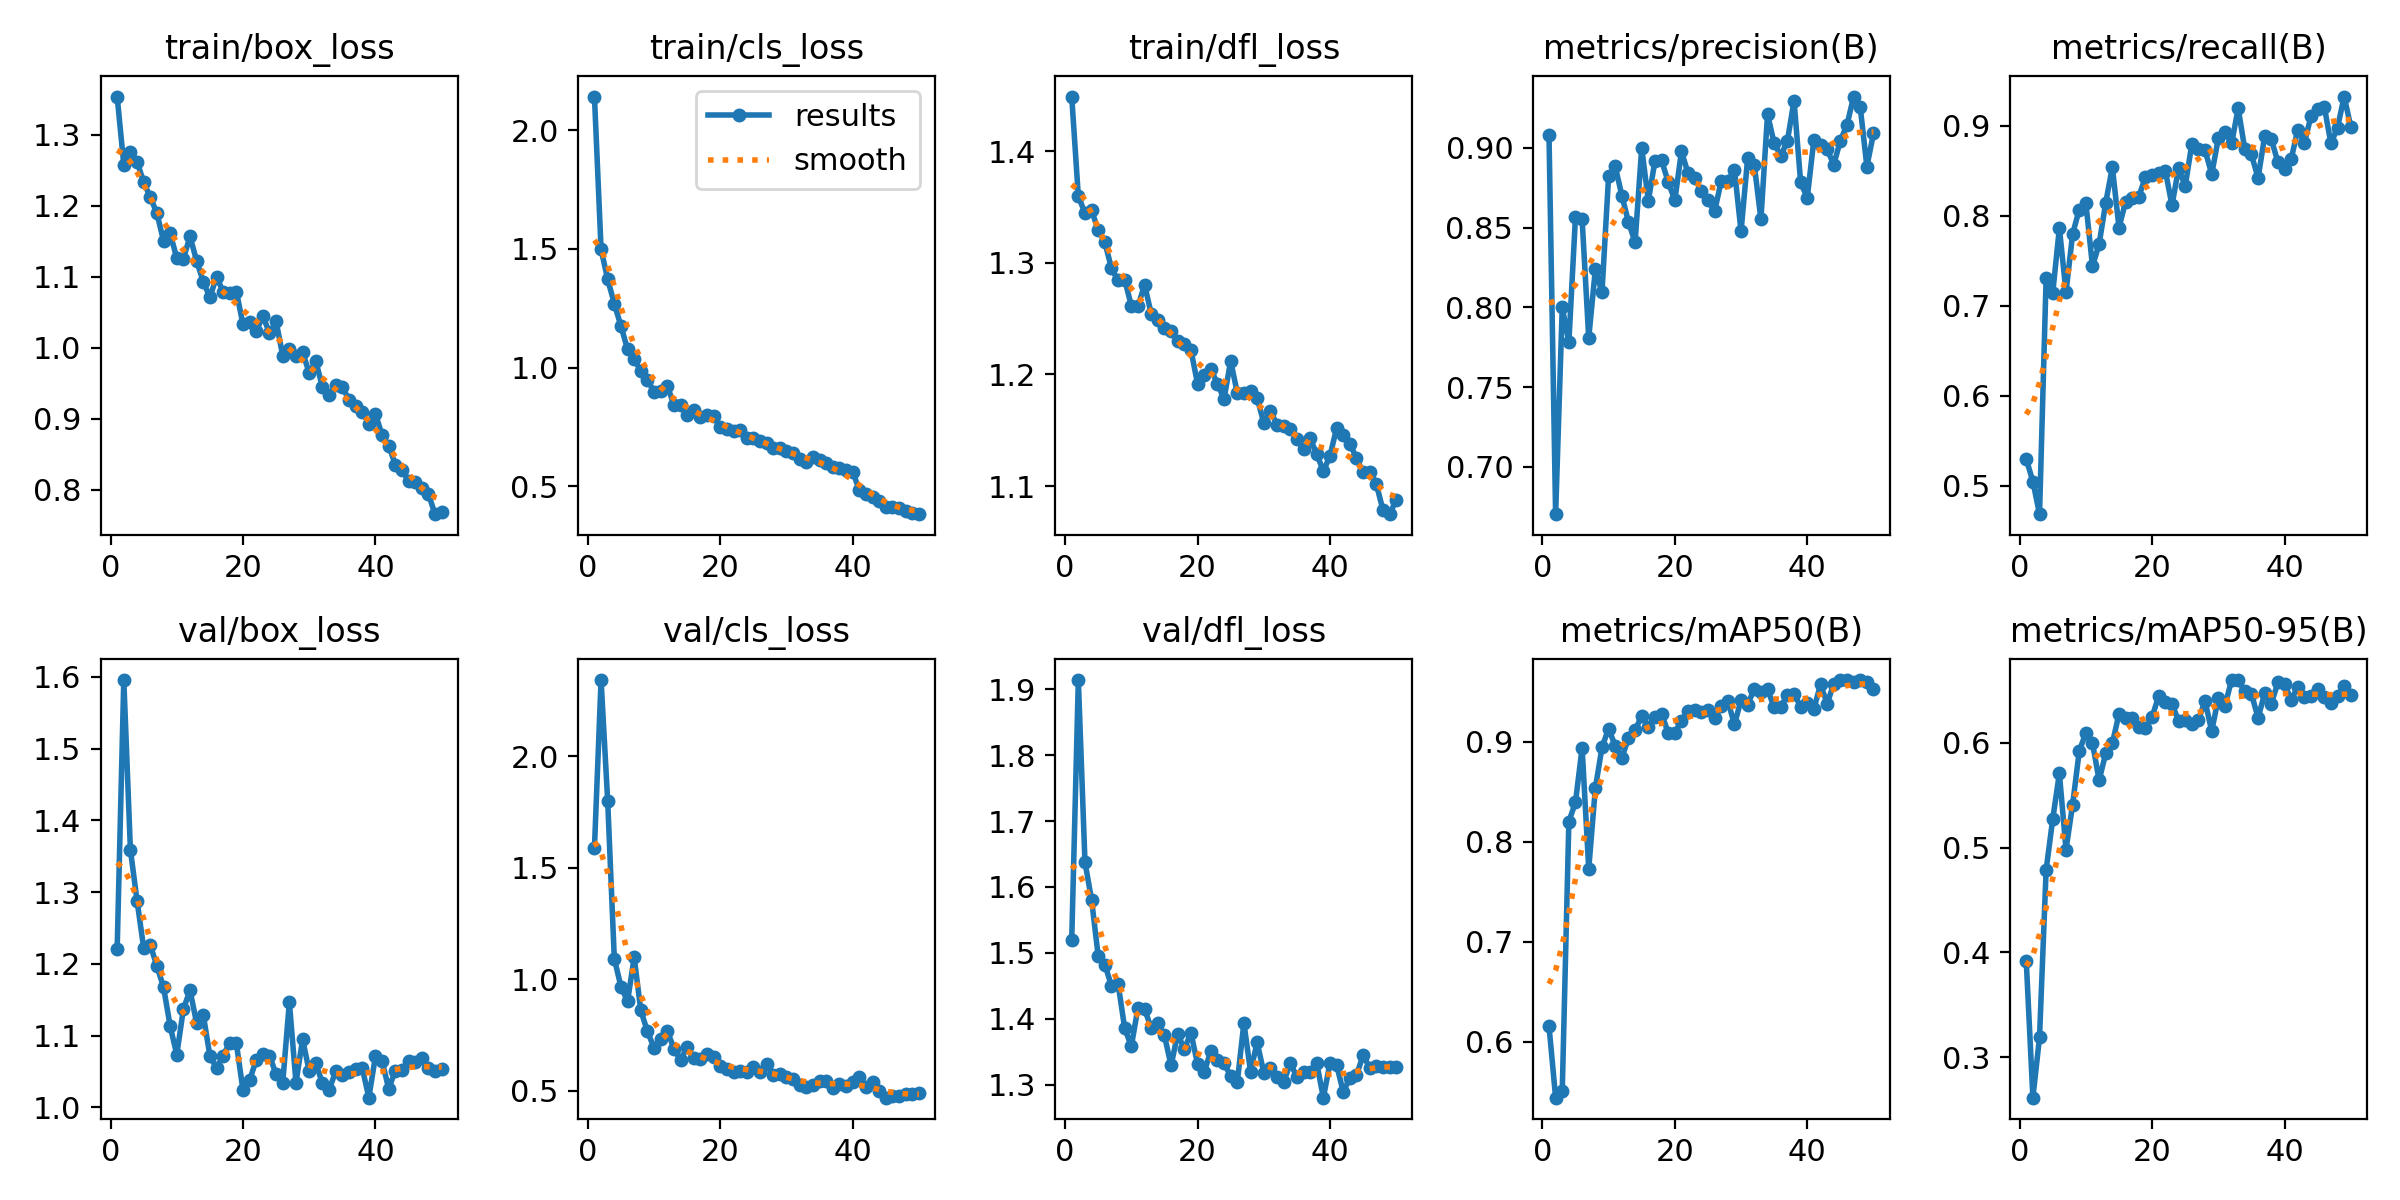

In [ ]:
from IPython.display import Image

run_dir = '/content/drive/MyDrive/mask_detection_yolo_model/mask_detector4/results.png'

Image(run_dir,width=900)  # all curves


In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/mask_detection_yolo_model/mask_detector4/weights/best.pt')


results = model.predict(
    source  = '/content/drive/MyDrive/mask_detection_yolo_model/data/images/test',
    conf    = 0.5,
    save    = True,
    project = '/content/drive/MyDrive/mask_detection_yolo_model/mask_detector4/runs/detect',
    name    = 'predict'
)

print("Saved to:", results[0].save_dir)




image 1/151 /content/drive/MyDrive/mask_detection_yolo_model/data/images/test/11-with-mask.jpg: 448x640 1 with_mask, 9.5ms
image 2/151 /content/drive/MyDrive/mask_detection_yolo_model/data/images/test/119-with-mask.jpg: 640x480 1 with_mask, 27.8ms
image 3/151 /content/drive/MyDrive/mask_detection_yolo_model/data/images/test/141-with-mask.jpg: 640x512 1 with_mask, 11.8ms
image 4/151 /content/drive/MyDrive/mask_detection_yolo_model/data/images/test/147-with-mask.jpg: 640x512 1 with_mask, 6.7ms
image 5/151 /content/drive/MyDrive/mask_detection_yolo_model/data/images/test/152-with-mask.jpg: 640x544 1 with_mask, 7.7ms
image 6/151 /content/drive/MyDrive/mask_detection_yolo_model/data/images/test/156-with-mask.jpg: 480x640 1 with_mask, 6.8ms
image 7/151 /content/drive/MyDrive/mask_detection_yolo_model/data/images/test/179-with-mask.jpg: 640x480 1 with_mask, 8.3ms
image 8/151 /content/drive/MyDrive/mask_detection_yolo_model/data/images/test/184-with-mask.jpg: 640x544 1 with_mask, 10.9ms
image

In [ ]:
!pip install gradio -q

import gradio as gr
from ultralytics import YOLO
from PIL import Image as PILImage
import numpy as np

# Your trained model
best_path = '/content/drive/MyDrive/mask_detection_yolo_model/mask_detector4/weights/best.pt'
model = YOLO(best_path)

def detect_mask(image):
    results = model(image, conf=0.5)[0]
    annotated = results.plot()

    labels = [model.names[int(c)] for c in results.boxes.cls]
    with_mask    = labels.count('with_mask')
    without_mask = labels.count('without_mask')

    if without_mask > 0:
        summary = f"ALERTE — {without_mask} personne(s) sans masque !"
    else:
        summary = f"OK — {with_mask} personne(s) avec masque detectee(s)"

    return annotated, summary

demo = gr.Interface(
    fn          = detect_mask,
    inputs      = gr.Image(type='numpy', label='Upload image'),
    outputs     = [gr.Image(label='Detection result'),
                   gr.Textbox(label='Résultat')],
    title       = 'Contrôle masque — Salle d\'opération',
    description = 'Uploadez une photo pour détecter si les personnes portent un masque.',
    examples    = []
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2026/04/01 10:54:56 [W] [service.go:132] login to server failed: session shutdown


<IPython.core.display.Javascript object>